In [1]:
import pandas as pd
import numpy as np

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
app = pd.read_csv("/kaggle/input/datasets/anggundwilestari/home-credit/HC_application_train.csv")

bureau = pd.read_csv("/kaggle/input/datasets/anggundwilestari/home-credit/HC_bureau.csv")

bureau_balance = pd.read_csv("/kaggle/input/datasets/anggundwilestari/home-credit/HC_bureau_balance.csv")

previous = pd.read_csv("/kaggle/input/datasets/anggundwilestari/home-credit/HC_previous_application.csv")

installments = pd.read_csv("/kaggle/input/datasets/anggundwilestari/home-credit/HC_installments_payments.csv")

credit_card = pd.read_csv("/kaggle/input/datasets/anggundwilestari/home-credit/HC_credit_card_balance.csv")

pos_cash = pd.read_csv("/kaggle/input/datasets/anggundwilestari/home-credit/HC_POS_CASH_balance.csv")

In [3]:
datasets = {
    "Application": app,
    "Bureau": bureau,
    "Previous": previous,
    "Installments": installments,
    "CreditCard": credit_card,
    "POS_CASH": pos_cash
}

for name, df in datasets.items():
    print("="*50)
    print(name)
    print(df.shape)

Application
(307511, 122)
Bureau
(1716428, 17)
Previous
(1670214, 37)
Installments
(13605401, 8)
CreditCard
(3840312, 23)
POS_CASH
(10001358, 8)


In [4]:
missing_report = pd.DataFrame()

missing_report["Column"] = app.columns
missing_report["Missing_%"] = (
    app.isnull().mean()*100
).values

missing_report.sort_values(
    "Missing_%",
    ascending=False
).head(30)

,Column,Missing_%
48,COMMONAREA_AVG,69.872297
62,COMMONAREA_MODE,69.872297
76,COMMONAREA_MEDI,69.872297
84,NONLIVINGAPARTMENTS_MEDI,69.432963
70,NONLIVINGAPARTMENTS_MODE,69.432963
56,NONLIVINGAPARTMENTS_AVG,69.432963
86,FONDKAPREMONT_MODE,68.386172
54,LIVINGAPARTMENTS_AVG,68.354953
82,LIVINGAPARTMENTS_MEDI,68.354953
68,LIVINGAPARTMENTS_MODE,68.354953


In [5]:
bureau_agg = bureau.groupby("SK_ID_CURR").agg({

    "DAYS_CREDIT":["mean","max","min"],

    "AMT_CREDIT_SUM":["mean","sum"],

    "AMT_CREDIT_SUM_DEBT":["mean","sum"],

    "AMT_CREDIT_SUM_OVERDUE":["mean","sum"]

})

bureau_agg.columns = [

    "_".join(col)
    for col in bureau_agg.columns
]

bureau_agg.reset_index(inplace=True)

bureau_agg.head()

,SK_ID_CURR,DAYS_CREDIT_mean,DAYS_CREDIT_max,DAYS_CREDIT_min,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_sum
0,100001,-735.000000,-49,-1572,207623.571429,1453365.000,85240.928571,596686.5,0.0,0.0
1,100002,-874.000000,-103,-1437,108131.945625,865055.565,49156.200000,245781.0,0.0,0.0
2,100003,-1400.750000,-606,-2586,254350.125000,1017400.500,0.000000,0.0,0.0,0.0
3,100004,-867.000000,-408,-1326,94518.900000,189037.800,0.000000,0.0,0.0,0.0
4,100005,-190.666667,-62,-373,219042.000000,657126.000,189469.500000,568408.5,0.0,0.0


In [6]:
previous_agg = previous.groupby("SK_ID_CURR").agg({

    "AMT_APPLICATION":["mean","max"],

    "AMT_CREDIT":["mean","max"],

    "CNT_PAYMENT":["mean","max"]

})

previous_agg.columns = [

    "_".join(col)
    for col in previous_agg.columns
]

previous_agg.reset_index(inplace=True)

In [7]:
installments["PAYMENT_DELAY"] = (

    installments["DAYS_ENTRY_PAYMENT"]
    -
    installments["DAYS_INSTALMENT"]

)

In [8]:
inst_agg = installments.groupby(
    "SK_ID_CURR"
).agg({

    "PAYMENT_DELAY":[
        "mean",
        "max",
        "sum"
    ],

    "AMT_PAYMENT":[
        "mean",
        "sum"
    ]

})

inst_agg.columns = [

    "_".join(col)
    for col in inst_agg.columns
]

inst_agg.reset_index(inplace=True)

In [9]:
credit_agg = credit_card.groupby(
    "SK_ID_CURR"
).agg({

    "AMT_BALANCE":[
        "mean",
        "max"
    ],

    "AMT_CREDIT_LIMIT_ACTUAL":[
        "mean"
    ]

})

credit_agg.columns = [

    "_".join(col)
    for col in credit_agg.columns
]

credit_agg.reset_index(inplace=True)

In [10]:
pos_agg = pos_cash.groupby(
    "SK_ID_CURR"
).agg({

    "SK_DPD":[
        "mean",
        "max"
    ],

    "SK_DPD_DEF":[
        "mean",
        "max"
    ]

})

pos_agg.columns = [

    "_".join(col)
    for col in pos_agg.columns
]

pos_agg.reset_index(inplace=True)

In [11]:
master = app.copy()

master = master.merge(
    bureau_agg,
    on="SK_ID_CURR",
    how="left"
)

master = master.merge(
    previous_agg,
    on="SK_ID_CURR",
    how="left"
)

master = master.merge(
    inst_agg,
    on="SK_ID_CURR",
    how="left"
)

master = master.merge(
    credit_agg,
    on="SK_ID_CURR",
    how="left"
)

master = master.merge(
    pos_agg,
    on="SK_ID_CURR",
    how="left"
)

master.shape

(307511, 149)

In [12]:
master["LOAN_INCOME_RATIO"] = (

    master["AMT_CREDIT"]
    /
    (master["AMT_INCOME_TOTAL"] + 1)
)

In [13]:
master["ANNUITY_INCOME_RATIO"] = (

    master["AMT_ANNUITY"]
    /
    (master["AMT_INCOME_TOTAL"] + 1)
)

In [14]:
master["DEBT_BURDEN"] = (

    master["AMT_CREDIT_SUM_DEBT_sum"]

    /

    (master["AMT_INCOME_TOTAL"] + 1)

)

In [15]:
master["HIGH_DEBT_FLAG"] = np.where(

    master["DEBT_BURDEN"] > 1,

    1,

    0

)

In [16]:
print(master.shape)

master.head()

(307511, 153)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_CREDIT_mean,DAYS_CREDIT_max,DAYS_CREDIT_min,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_sum,AMT_APPLICATION_mean,AMT_APPLICATION_max,AMT_CREDIT_mean,AMT_CREDIT_max,CNT_PAYMENT_mean,CNT_PAYMENT_max,PAYMENT_DELAY_mean,PAYMENT_DELAY_max,PAYMENT_DELAY_sum,AMT_PAYMENT_mean,AMT_PAYMENT_sum,AMT_BALANCE_mean,AMT_BALANCE_max,AMT_CREDIT_LIMIT_ACTUAL_mean,SK_DPD_mean,SK_DPD_max,SK_DPD_DEF_mean,SK_DPD_DEF_max,LOAN_INCOME_RATIO,ANNUITY_INCOME_RATIO,DEBT_BURDEN,HIGH_DEBT_FLAG
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,-874.00,-103.0,-1437.0,108131.945625,865055.565,49156.2,245781.0,0.0,0.0,179055.00,179055.0,179055.00,179055.0,24.000000,24.0,-20.421053,-12.0,-388.0,11559.247105,219625.695,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2.007879,0.121977,1.213727,1
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7

In [17]:
master.to_csv(
    "master_dataset_v1.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [18]:
# to check target distribution
master["TARGET"].value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [19]:
master["TARGET"].value_counts()
# non default - 0
# default - 1

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [20]:
# check for duplicate customers
master["SK_ID_CURR"].duplicated().sum()

np.int64(0)

In [21]:
master.to_parquet(
    "master_dataset_v1.parquet",
    index=False
)

# **Behavioral Intelligence Features ,Financial Stress Features,Customer Value Features,Risk Features**

In [22]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [23]:
master["AGE"] = (
    abs(master["DAYS_BIRTH"]) / 365
).astype(int)

master["AGE"].describe()

count    307511.000000
mean         43.435968
std          11.954593
min          20.000000
25%          34.000000
50%          43.000000
75%          53.000000
max          69.000000
Name: AGE, dtype: float64

In [24]:
# fixing weired values for missing employment
master["DAYS_EMPLOYED"] = master[
    "DAYS_EMPLOYED"
].replace(
    365243,
    np.nan
)

master["EMPLOYMENT_YEARS"] = (
    abs(master["DAYS_EMPLOYED"]) / 365
)

master["EMPLOYMENT_YEARS"].describe()

count    252137.000000
mean          6.531971
std           6.406466
min           0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: EMPLOYMENT_YEARS, dtype: float64

In [25]:
master["INCOME_PER_PERSON"] = (
    master["AMT_INCOME_TOTAL"]
    /
    master["CNT_FAM_MEMBERS"]
)

master["INCOME_PER_PERSON"].describe()

count    3.075090e+05
mean     9.310588e+04
std      1.013734e+05
min      2.812500e+03
25%      4.725000e+04
50%      7.500000e+04
75%      1.125000e+05
max      3.900000e+07
Name: INCOME_PER_PERSON, dtype: float64

In [26]:
master["LOAN_BURDEN"] = (
    master["AMT_CREDIT"]
    /
    (
        master["AMT_INCOME_TOTAL"]
        + 1
    )
)

master["LOAN_BURDEN"].describe()

count    307511.000000
mean          3.957537
std           2.689696
min           0.004808
25%           2.018659
50%           3.265042
75%           5.159857
max          84.733539
Name: LOAN_BURDEN, dtype: float64

In [27]:
master["ANNUITY_BURDEN"] = (
    master["AMT_ANNUITY"]
    /
    (
        master["AMT_INCOME_TOTAL"]
        + 1
    )
)

master["ANNUITY_BURDEN"].describe()

count    307499.000000
mean          0.180928
std           0.094573
min           0.000224
25%           0.114781
50%           0.162832
75%           0.229064
max           1.875892
Name: ANNUITY_BURDEN, dtype: float64

In [28]:
master["GOODS_CREDIT_RATIO"] = (
    master["AMT_GOODS_PRICE"]
    /
    (
        master["AMT_CREDIT"]
        + 1
    )
)

master["GOODS_CREDIT_RATIO"].describe()

count    307233.000000
mean          0.900687
std           0.096630
min           0.166666
25%           0.834723
50%           0.893814
75%           0.999996
max           6.666617
Name: GOODS_CREDIT_RATIO, dtype: float64

In [29]:
master["CREDIT_DEPENDENCY"] = (
    master["AMT_CREDIT_SUM_DEBT_sum"]
    /
    (
        master["AMT_CREDIT_SUM_sum"]
        + 1
    )
)

master["CREDIT_DEPENDENCY"].describe()

count    2.634910e+05
mean    -1.050989e+00
std      7.500605e+03
min     -3.112461e+06
25%      0.000000e+00
50%      2.071405e-01
75%      4.818718e-01
max      2.250000e+06
Name: CREDIT_DEPENDENCY, dtype: float64

In [30]:
master["OVERDUE_RATIO"] = (
    master["AMT_CREDIT_SUM_OVERDUE_sum"]
    /
    (
        master["AMT_CREDIT_SUM_sum"]
        + 1
    )
)

master["OVERDUE_RATIO"].describe()

count    263491.000000
mean          0.000246
std           0.036057
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          14.705335
Name: OVERDUE_RATIO, dtype: float64

In [31]:
risk_features = [

    "LOAN_BURDEN",

    "ANNUITY_BURDEN",

    "CREDIT_DEPENDENCY",

    "OVERDUE_RATIO"

]

In [32]:
master[risk_features] = (
    master[risk_features]
    .fillna(0)
)

In [33]:
scaler = MinMaxScaler()

scaled_risk = scaler.fit_transform(
    master[risk_features]
)

scaled_risk = pd.DataFrame(

    scaled_risk,

    columns=risk_features
)

In [34]:
master["FINANCIAL_STRESS_SCORE"] = (
    scaled_risk.mean(axis=1)
)

master["FINANCIAL_STRESS_SCORE"].describe()

count    307511.000000
mean          0.180882
std           0.019492
min           0.038442
25%           0.167142
50%           0.177059
75%           0.190635
max           0.645104
Name: FINANCIAL_STRESS_SCORE, dtype: float64

In [35]:
master["STRESS_CATEGORY"] = pd.qcut(

    master["FINANCIAL_STRESS_SCORE"],

    q=3,

    labels=[
        "Low",
        "Medium",
        "High"
    ]

)

In [36]:
master["STRESS_CATEGORY"].value_counts()

STRESS_CATEGORY
Low       102504
High      102504
Medium    102503
Name: count, dtype: int64

In [37]:
pd.crosstab(

    master["STRESS_CATEGORY"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
STRESS_CATEGORY,,
Low,92.380785,7.619215
Medium,91.642196,8.357804
High,91.758370,8.241630


In [38]:
master["AGE_GROUP"] = pd.cut(

    master["AGE"],

    bins=[18,25,35,45,55,65,100],

    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

In [39]:
master["INCOME_GROUP"] = pd.qcut(

    master["AMT_INCOME_TOTAL"],

    q=5,

    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [40]:
master["LOAN_SIZE_GROUP"] = pd.qcut(

    master["AMT_CREDIT"],

    q=5,

    labels=[
        "Very Small",
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ]
)

In [41]:
income_rank = master[
    "AMT_INCOME_TOTAL"
].rank(pct=True)

credit_rank = master[
    "AMT_CREDIT"
].rank(pct=True)

master["CUSTOMER_VALUE_SCORE"] = (
    income_rank +
    credit_rank
)/2

In [42]:
master["VALUE_SEGMENT"] = pd.qcut(

    master["CUSTOMER_VALUE_SCORE"],

    q=4,

    labels=[
        "Bronze",
        "Silver",
        "Gold",
        "Platinum"
    ]
)

In [43]:
pd.crosstab(

    master["VALUE_SEGMENT"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
VALUE_SEGMENT,,
Bronze,91.919665,8.080335
Silver,90.936120,9.063880
Gold,91.412529,8.587471
Platinum,93.441770,6.558230


In [44]:
#Income vs Default
pd.crosstab(

    master["INCOME_GROUP"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
INCOME_GROUP,,
Very Low,91.793752,8.206248
Low,91.411680,8.588320
Medium,91.315262,8.684738
High,91.943109,8.056891
Very High,93.480199,6.519801


In [45]:
#Education vs Default
pd.crosstab(

    master["NAME_EDUCATION_TYPE"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
NAME_EDUCATION_TYPE,,
Academic degree,98.170732,1.829268
Higher education,94.644885,5.355115
Incomplete higher,91.515034,8.484966
Lower secondary,89.072327,10.927673
Secondary / secondary special,91.060071,8.939929


In [46]:
#Occupation vs Default
pd.crosstab(

    master["OCCUPATION_TYPE"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
OCCUPATION_TYPE,,
Accountants,95.169673,4.830327
Cleaning staff,90.393295,9.606705
Cooking staff,89.556004,10.443996
Core staff,93.696046,6.303954
Drivers,88.673870,11.326130
HR staff,93.605684,6.394316
High skill tech staff,93.840070,6.159930
IT staff,93.536122,6.463878
Laborers,89.421230,10.578770


In [47]:
#Contract Type vs Default
pd.crosstab(

    master["NAME_CONTRACT_TYPE"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,91.654087,8.345913
Revolving loans,94.521671,5.478329


# **Risk Analytics & Business Insights**

In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

In [49]:
print(master.shape)

(307511, 168)


In [50]:
#Creating Income Risk Indicator

master["LOW_INCOME_FLAG"] = np.where(

    master["AMT_INCOME_TOTAL"]
    <
    master["AMT_INCOME_TOTAL"].median(),
    1,
    0
)

In [51]:
master["HIGH_LOAN_BURDEN"] = np.where(

    master["LOAN_BURDEN"]

    >

    master["LOAN_BURDEN"].quantile(0.75),

    1,

    0
)

In [52]:
master["HIGH_CREDIT_DEPENDENCY"] = np.where(

    master["CREDIT_DEPENDENCY"]

    >

    master["CREDIT_DEPENDENCY"].quantile(0.75),

    1,

    0
)

In [53]:
master["RISK_SCORE"] = (

    master["LOW_INCOME_FLAG"]

    +

    master["HIGH_LOAN_BURDEN"]

    +

    master["HIGH_CREDIT_DEPENDENCY"]

)

In [54]:
master["RISK_BAND"] = pd.cut(

    master["RISK_SCORE"],

    bins=[-1,0,1,2,3],

    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High"
    ]
)

In [55]:
pd.crosstab(

    master["RISK_BAND"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
RISK_BAND,,
Very Low,93.053689,6.946311
Low,91.918603,8.081397
Medium,90.936669,9.063331
High,88.932700,11.067300


In [56]:
age_risk = pd.crosstab(

    master["AGE_GROUP"],

    master["TARGET"],

    normalize="index"

)*100

age_risk

TARGET,0,1
AGE_GROUP,,
18-25,88.258365,11.741635
26-35,89.414554,10.585446
36-45,91.762372,8.237628
46-55,93.151178,6.848822
56-65,94.656716,5.343284
65+,96.626073,3.373927


In [57]:
income_risk = pd.crosstab(

    master["INCOME_GROUP"],

    master["TARGET"],

    normalize="index"

)*100

income_risk

TARGET,0,1
INCOME_GROUP,,
Very Low,91.793752,8.206248
Low,91.411680,8.588320
Medium,91.315262,8.684738
High,91.943109,8.056891
Very High,93.480199,6.519801


In [58]:
education_risk = pd.crosstab(

    master["NAME_EDUCATION_TYPE"],

    master["TARGET"],

    normalize="index"

)*100

education_risk.sort_values(
    1,
    ascending=False
)

TARGET,0,1
NAME_EDUCATION_TYPE,,
Lower secondary,89.072327,10.927673
Secondary / secondary special,91.060071,8.939929
Incomplete higher,91.515034,8.484966
Higher education,94.644885,5.355115
Academic degree,98.170732,1.829268


In [59]:
occupation_risk = pd.crosstab(

    master["OCCUPATION_TYPE"],

    master["TARGET"],

    normalize="index"

)*100

occupation_risk.sort_values(
    1,
    ascending=False
)

TARGET,0,1
OCCUPATION_TYPE,,
Low-skill Laborers,82.847587,17.152413
Drivers,88.673870,11.326130
Waiters/barmen staff,88.724036,11.275964
Security staff,89.257551,10.742449
Laborers,89.421230,10.578770
Cooking staff,89.556004,10.443996
Sales staff,90.368201,9.631799
Cleaning staff,90.393295,9.606705
Realty agents,92.143808,7.856192


In [60]:
contract_risk = pd.crosstab(

    master["NAME_CONTRACT_TYPE"],

    master["TARGET"],

    normalize="index"

)*100

contract_risk

TARGET,0,1
NAME_CONTRACT_TYPE,,
Cash loans,91.654087,8.345913
Revolving loans,94.521671,5.478329


In [61]:
corr_target = (

    master
    .select_dtypes(
        include=np.number
    )
    .corr()["TARGET"]
    .abs()
    .sort_values(
        ascending=False
    )
)

corr_target.head(20)

TARGET                         1.000000
EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
DAYS_CREDIT_mean               0.089729
AMT_BALANCE_mean               0.087177
DAYS_BIRTH                     0.078239
AGE                            0.078234
DAYS_CREDIT_min                0.075248
DAYS_EMPLOYED                  0.074958
EMPLOYMENT_YEARS               0.074958
AMT_BALANCE_max                0.068798
GOODS_CREDIT_RATIO             0.065407
HIGH_CREDIT_DEPENDENCY         0.065108
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_CREDIT_max                0.049782
Name: TARGET, dtype: float64

# **Persona Creation , will create business segments**

In [62]:
master["EXT_RISK_SCORE"] = (

    master[[
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3"
    ]]

    .mean(axis=1)

)

In [63]:
master["EXT_RISK_GROUP"] = pd.qcut(

    master["EXT_RISK_SCORE"],

    q=4,

    labels=[
        "Very High Risk",
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ]

)

In [64]:
pd.crosstab(

    master["EXT_RISK_GROUP"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
EXT_RISK_GROUP,,
Very High Risk,82.714909,17.285091
High Risk,92.288671,7.711329
Medium Risk,95.417393,4.582607
Low Risk,97.287694,2.712306


# **Customer Personas, now i will create meaningful segments.**

In [65]:
master["PRIME_BORROWER"] = np.where(

    (master["AMT_INCOME_TOTAL"] >
     master["AMT_INCOME_TOTAL"].quantile(0.75))

    &

    (master["EXT_RISK_SCORE"] >
     master["EXT_RISK_SCORE"].quantile(0.75)),

    1,

    0
)

In [66]:
master["FINANCIALLY_STRESSED"] = np.where(

    (master["LOAN_BURDEN"] >
     master["LOAN_BURDEN"].quantile(0.75))

    |

    (master["CREDIT_DEPENDENCY"] >
     master["CREDIT_DEPENDENCY"].quantile(0.75)),

    1,

    0
)

In [67]:
master["GROWTH_CUSTOMER"] = np.where(

    (master["AGE"] < 35)

    &

    (
        master["AMT_INCOME_TOTAL"]
        >
        master["AMT_INCOME_TOTAL"].median()
    ),

    1,

    0
)

In [68]:
master["PERSONA"] = "Standard"

master.loc[
    master["PRIME_BORROWER"] == 1,
    "PERSONA"
] = "Prime Borrower"

master.loc[
    master["FINANCIALLY_STRESSED"] == 1,
    "PERSONA"
] = "Financially Stressed"

master.loc[
    master["GROWTH_CUSTOMER"] == 1,
    "PERSONA"
] = "Growth Borrower"

In [69]:
master["PERSONA"].value_counts()

PERSONA
Standard                133915
Financially Stressed    118960
Growth Borrower          42171
Prime Borrower           12465
Name: count, dtype: int64

In [70]:
pd.crosstab(

    master["PERSONA"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
PERSONA,,
Financially Stressed,91.109617,8.890383
Growth Borrower,90.211283,9.788717
Prime Borrower,97.665463,2.334537
Standard,92.659523,7.340477


In [71]:
master.to_parquet(
    "master_dataset_v2.parquet",
    index=False
)

print("Saved")

Saved


# **Early Warning Engine**

In [72]:
master["RISK_PERCENTILE"] = (
    master["EXT_RISK_SCORE"]
    .rank(pct=True)
)

In [73]:
master["EARLY_WARNING"] = pd.cut(

    master["RISK_PERCENTILE"],

    bins=[0,0.33,0.66,1],

    labels=[
        "Red",
        "Amber",
        "Green"
    ],

    include_lowest=True
)

In [74]:
master["EARLY_WARNING"].value_counts()

EARLY_WARNING
Green    104496
Amber    101422
Red      101421
Name: count, dtype: int64

**Default Rate by Warning Level**

In [75]:
pd.crosstab(

    master["EARLY_WARNING"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
EARLY_WARNING,,
Red,84.682659,15.317341
Amber,93.972708,6.027292
Green,96.973090,3.026910


**Insight : Customers in the red warning zone are more likely to default than customers in the Green Zone.(15.3 / 3.0~ 5.1**

# **Customer Segmentation**

In [76]:
segment_features = [

    "AGE",

    "AMT_INCOME_TOTAL",

    "LOAN_BURDEN",

    "ANNUITY_BURDEN",

    "EXT_RISK_SCORE",

    "CUSTOMER_VALUE_SCORE",

    "FINANCIAL_STRESS_SCORE"

]

In [77]:
segment_df = master[
    segment_features
].copy()

segment_df = segment_df.fillna(
    segment_df.median()
)

In [78]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

segment_scaled = scaler.fit_transform(
    segment_df
)

In [79]:
#Elbow Method

from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(segment_scaled)

    inertia.append(
        kmeans.inertia_
    )

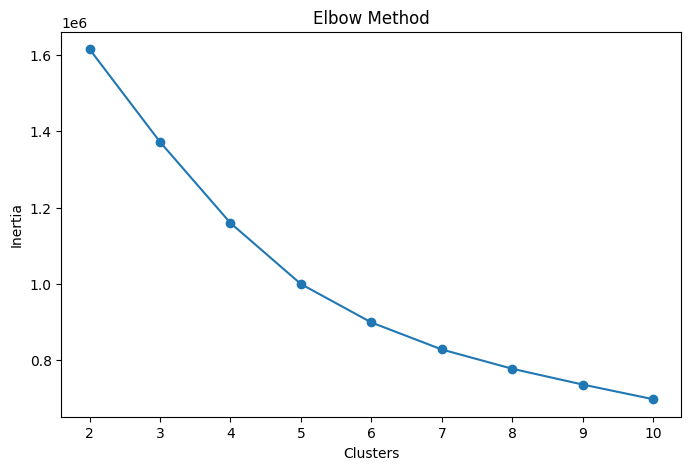

In [80]:
#Ploting Elbow Curve

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [81]:
# Training final Kmean
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

master["CLUSTER"] = kmeans.fit_predict(
    segment_scaled
)

master["CLUSTER"].value_counts()

CLUSTER
0    90149
4    85264
1    73741
2    58356
3        1
Name: count, dtype: int64

In [82]:
cluster_summary = master.groupby(
    "CLUSTER"
)[
    [
        "AGE",
        "AMT_INCOME_TOTAL",
        "LOAN_BURDEN",
        "EXT_RISK_SCORE",
        "CUSTOMER_VALUE_SCORE",
        "FINANCIAL_STRESS_SCORE",
        "TARGET"
    ]
].mean()

cluster_summary

,AGE,AMT_INCOME_TOTAL,LOAN_BURDEN,EXT_RISK_SCORE,CUSTOMER_VALUE_SCORE,FINANCIAL_STRESS_SCORE,TARGET
CLUSTER,,,,,,,
0,43.945402,2.517756e+05,3.883539,0.563116,0.754865,0.177643,0.057993
1,53.599666,1.276804e+05,2.565805,0.572068,0.309208,0.171700,0.045972
2,45.689149,1.152766e+05,7.980009,0.522252,0.514062,0.211588,0.078621
3,34.000000,1.170000e+08,0.004808,0.239838,0.783665,0.145134,1.000000
4,32.565221,1.518876e+05,2.486427,0.389052,0.385919,0.171232,0.136259


In [83]:
pd.crosstab(

    master["CLUSTER"],

    master["TARGET"],

    normalize="index"

)*100

TARGET,0,1
CLUSTER,,
0,94.200712,5.799288
1,95.402829,4.597171
2,92.137912,7.862088
3,0.000000,100.000000
4,86.374085,13.625915


In [84]:
master[master["CLUSTER"] == 3].shape

(1, 182)

In [85]:
master_clean = master[
    master["CLUSTER"] != 3
].copy()

print(master_clean.shape)

(307510, 182)


In [86]:
segment_map = {

    0:"Prime High Value",

    1:"Mature Stable",

    2:"Credit Dependent",

    4:"Young High Risk"

}

master_clean["SEGMENT"] = (
    master_clean["CLUSTER"]
    .map(segment_map)
)

In [87]:
master_clean["SEGMENT"].value_counts()

SEGMENT
Prime High Value    90149
Young High Risk     85264
Mature Stable       73741
Credit Dependent    58356
Name: count, dtype: int64

In [88]:
segment_risk = pd.crosstab(

    master_clean["SEGMENT"],

    master_clean["TARGET"],

    normalize="index"

)*100

segment_risk

TARGET,0,1
SEGMENT,,
Credit Dependent,92.137912,7.862088
Mature Stable,95.402829,4.597171
Prime High Value,94.200712,5.799288
Young High Risk,86.374085,13.625915


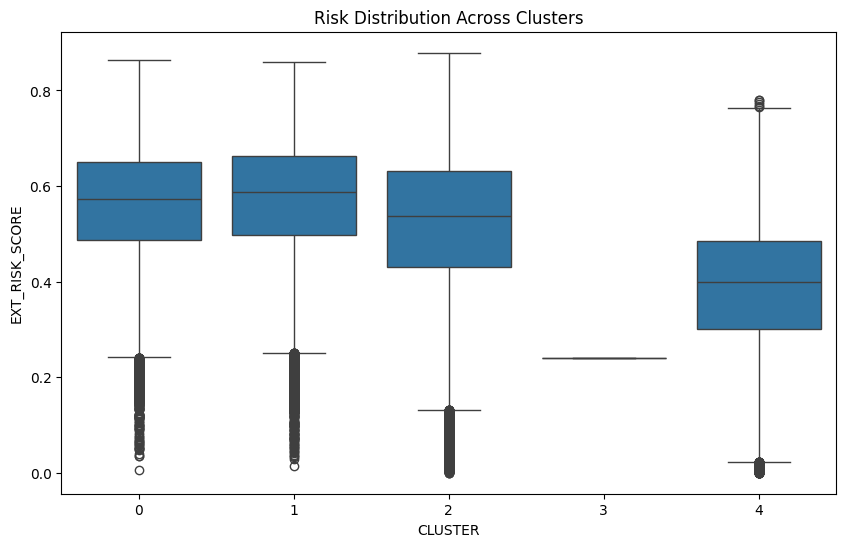

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=master,
    x="CLUSTER",
    y="EXT_RISK_SCORE"
)

plt.title(
    "Risk Distribution Across Clusters"
)

plt.show()

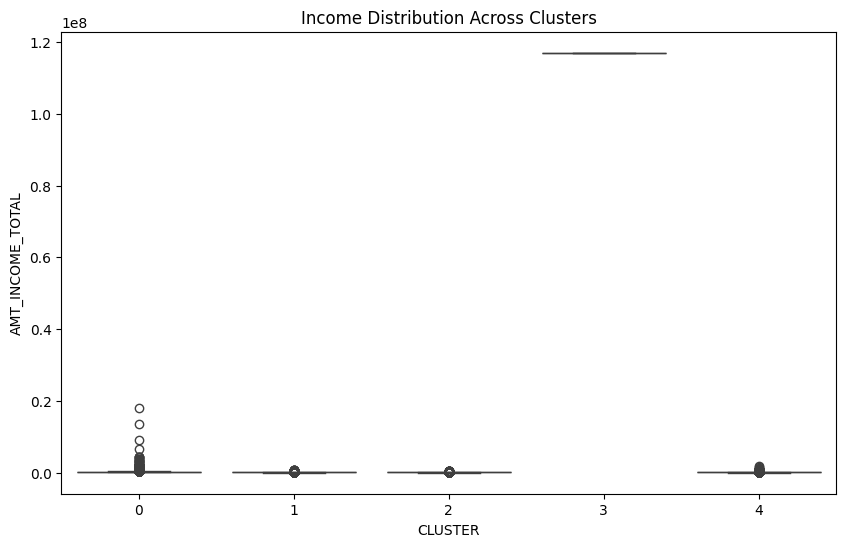

In [90]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=master,
    x="CLUSTER",
    y="AMT_INCOME_TOTAL"
)

plt.title(
    "Income Distribution Across Clusters"
)

plt.show()

In [91]:
pd.crosstab(

    master_clean["SEGMENT"],

    master_clean["EARLY_WARNING"],

    normalize="index"

)*100

EARLY_WARNING,Red,Amber,Green
SEGMENT,,,
Credit Dependent,29.293172,33.726492,36.980336
Mature Stable,16.602662,32.958354,50.438983
Prime High Value,17.602344,37.272092,45.125565
Young High Risk,66.003920,28.020798,5.975282


# MODELING (CLEAN VERSION)

In [92]:
print(master_clean.shape)

master_clean.head()

(307510, 183)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,DAYS_CREDIT_mean,DAYS_CREDIT_max,DAYS_CREDIT_min,AMT_CREDIT_SUM_mean,AMT_CREDIT_SUM_sum,AMT_CREDIT_SUM_DEBT_mean,AMT_CREDIT_SUM_DEBT_sum,AMT_CREDIT_SUM_OVERDUE_mean,AMT_CREDIT_SUM_OVERDUE_sum,AMT_APPLICATION_mean,AMT_APPLICATION_max,AMT_CREDIT_mean,AMT_CREDIT_max,CNT_PAYMENT_mean,CNT_PAYMENT_max,PAYMENT_DELAY_mean,PAYMENT_DELAY_max,PAYMENT_DELAY_sum,AMT_PAYMENT_mean,AMT_PAYMENT_sum,AMT_BALANCE_mean,AMT_BALANCE_max,AMT_CREDIT_LIMIT_ACTUAL_mean,SK_DPD_mean,SK_DPD_max,SK_DPD_DEF_mean,SK_DPD_DEF_max,LOAN_INCOME_RATIO,ANNUITY_INCOME_RATIO,DEBT_BURDEN,HIGH_DEBT_FLAG,AGE,EMPLOYMENT_YEARS,INCOME_PER_PERSON,LOAN_BURDEN,ANNUITY_BURDEN,GOODS_CREDIT_RATIO,CREDIT_DEPENDENCY,OVERDUE_RATIO,FINANCIAL_STRESS_SCORE,STRESS_CATEGORY,AGE_GROUP,INCOME_GROUP,LOAN_SIZE_GROUP,CUSTOMER_VALUE_SCORE,VALUE_SEGMENT,LOW_INCOME_FLAG,HIGH_LOAN_BURDEN,HIGH_CREDIT_DEPENDENCY,RISK_SCORE,RISK_BAND,EXT_RISK_SCORE,EXT_RISK_GROUP,PRIME_BORROWER,FINANCIALLY_STRESSED,GROWTH_CUSTOMER,PERSONA,RISK_PERCENTILE,EARLY_WARNING,CLUSTER,SEGMENT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,-874.00,-103.0,-1437.0,108131.945625,865055.565,49156.2,245781

# LIGHTGBM MODELING 

In [93]:
drop_cols = [

    "SK_ID_CURR",

    "TARGET",

    "PERSONA",

    "SEGMENT",

    "EARLY_WARNING",

    "AGE_GROUP",

    "INCOME_GROUP",

    "LOAN_SIZE_GROUP",

    "VALUE_SEGMENT",

    "STRESS_CATEGORY"

]

X = master_clean.drop(
    columns=[c for c in drop_cols if c in master_clean.columns]
).copy()

y = master_clean["TARGET"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (307510, 173)
y Shape: (307510,)


In [94]:
cat_cols = X.select_dtypes(
    include=["object", "category"]
).columns

for col in cat_cols:
    X[col] = X[col].astype(str)

print("Categorical Columns:", len(cat_cols))

Categorical Columns: 18


In [95]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(307510, 292)


In [96]:
import re

X.columns = [

    re.sub(
        r"[^A-Za-z0-9_]",
        "_",
        str(col)
    )

    for col in X.columns
]

In [97]:
print(
    X.select_dtypes(
        exclude=np.number
    ).shape
)

(307510, 137)


In [98]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(
    X.median()
)

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print(X_train.shape)
print(X_test.shape)

(246008, 292)
(61502, 292)


In [100]:
!pip install lightgbm -q

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [101]:
lgbm = LGBMClassifier(

    n_estimators=300,

    learning_rate=0.05,

    num_leaves=31,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    class_weight="balanced"
)

lgbm.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Number of positive: 19859, number of negative: 226149
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.124521 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 21466
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 282
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, max_depth=8, n_estimators=300,
               random_state=42, subsample=0.8)

In [102]:
y_pred = lgbm.predict(X_test)

y_prob = lgbm.predict_proba(
    X_test
)[:,1]

In [103]:
print(classification_report(
    y_test,
    y_pred
))

print(
    "ROC AUC:",
    roc_auc_score(
        y_test,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       0.96      0.74      0.83     56537
           1       0.18      0.67      0.29      4965

    accuracy                           0.73     61502
   macro avg       0.57      0.70      0.56     61502
weighted avg       0.90      0.73      0.79     61502

ROC AUC: 0.772706695243876


In [104]:
feature_imp = pd.DataFrame({

    "Feature": X.columns,

    "Importance": lgbm.feature_importances_

})

feature_imp = feature_imp.sort_values(
    "Importance",
    ascending=False
)

feature_imp.head(20)

,Feature,Importance
123,AMT_PAYMENT_sum,294
149,EXT_RISK_SCORE,293
6,DAYS_BIRTH,262
27,EXT_SOURCE_1,246
3,AMT_ANNUITY,233
120,PAYMENT_DELAY_max,226
140,GOODS_CREDIT_RATIO,218
29,EXT_SOURCE_3,217
121,PAYMENT_DELAY_sum,214
117,CNT_PAYMENT_mean,212


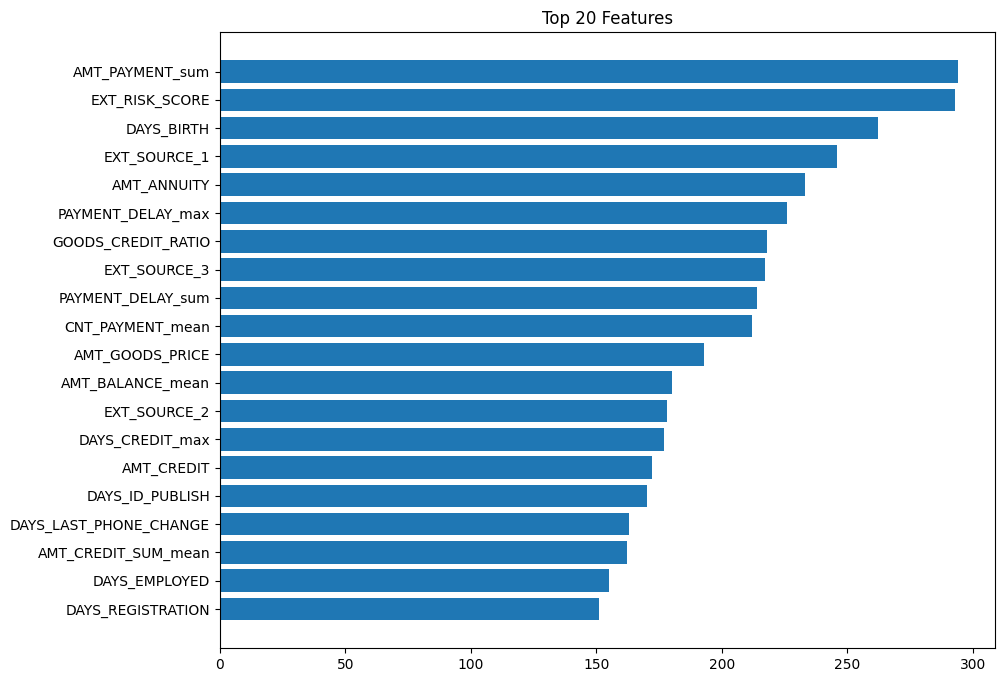

In [105]:
import matplotlib.pyplot as plt

top20 = feature_imp.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Features"
)

plt.show()

**SHAP**

In [106]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(
    lgbm
)

shap_values = explainer.shap_values(
    X_test
)

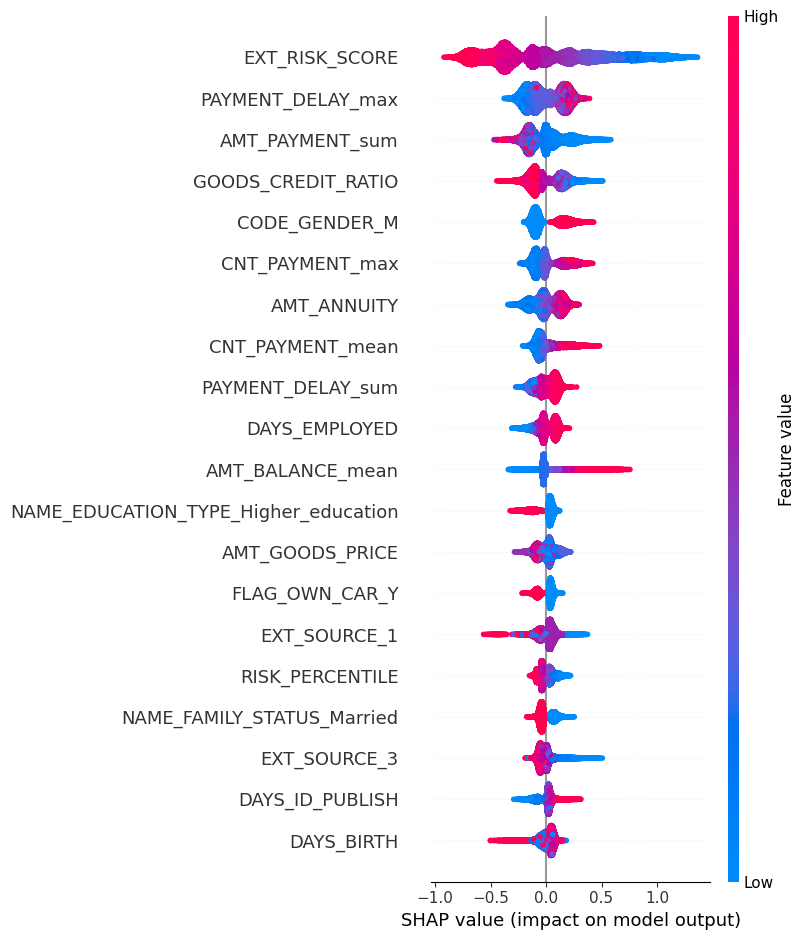

In [107]:
shap.summary_plot(

    shap_values,

    X_test,

    max_display=20
)

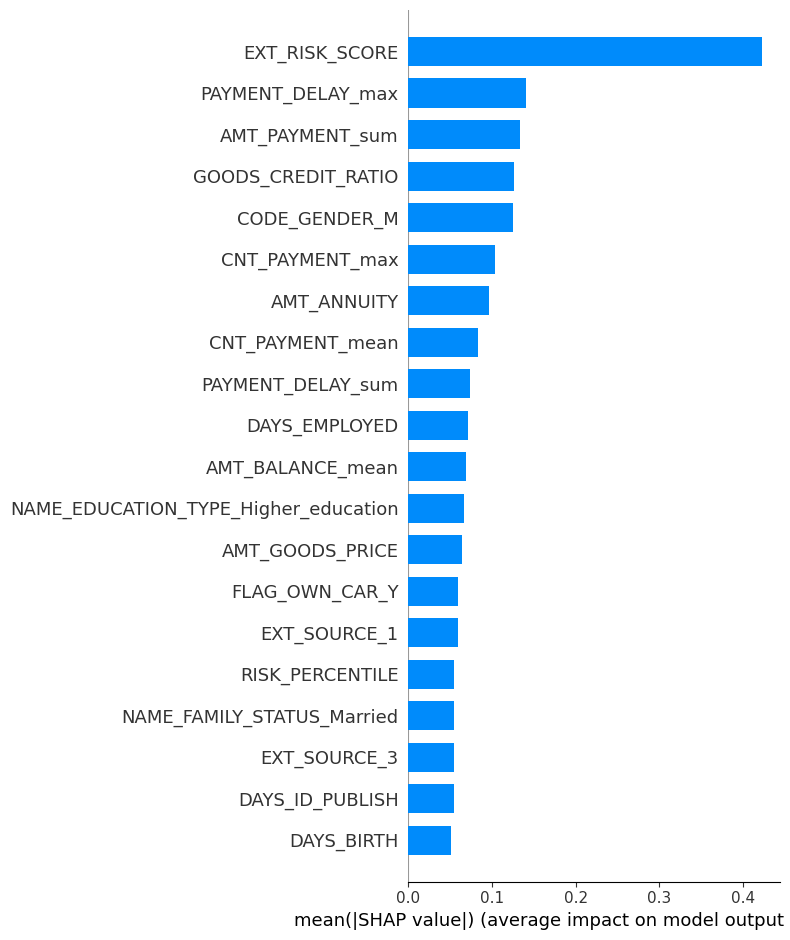

In [108]:
shap.summary_plot(

    shap_values,

    X_test,

    plot_type="bar",

    max_display=20
)

In [109]:
portfolio_summary = master_clean.groupby(
    "SEGMENT"
).agg({

    "TARGET":"mean",

    "AMT_CREDIT":"mean",

    "AMT_INCOME_TOTAL":"mean",

    "EXT_RISK_SCORE":"mean"

}).reset_index()

portfolio_summary

,SEGMENT,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL,EXT_RISK_SCORE
0,Credit Dependent,0.078621,895504.445096,115276.579025,0.522252
1,Mature Stable,0.045972,300399.330671,127680.354244,0.572068
2,Prime High Value,0.057993,888471.097339,251775.593047,0.563116
3,Young High Risk,0.136259,348352.602617,151887.572428,0.389052


In [110]:
portfolio_summary.columns = [

    "Segment",

    "Default_Rate",

    "Avg_Credit",

    "Avg_Income",

    "Avg_Risk_Score"
]

portfolio_summary

,Segment,Default_Rate,Avg_Credit,Avg_Income,Avg_Risk_Score
0,Credit Dependent,0.078621,895504.445096,115276.579025,0.522252
1,Mature Stable,0.045972,300399.330671,127680.354244,0.572068
2,Prime High Value,0.057993,888471.097339,251775.593047,0.563116
3,Young High Risk,0.136259,348352.602617,151887.572428,0.389052


In [111]:
pricing_map = {

    "Prime High Value":10,

    "Mature Stable":11,

    "Credit Dependent":14,

    "Young High Risk":18

}

portfolio_summary[
    "Recommended_Interest"
] = portfolio_summary[
    "Segment"
].map(pricing_map)

portfolio_summary

,Segment,Default_Rate,Avg_Credit,Avg_Income,Avg_Risk_Score,Recommended_Interest
0,Credit Dependent,0.078621,895504.445096,115276.579025,0.522252,14
1,Mature Stable,0.045972,300399.330671,127680.354244,0.572068,11
2,Prime High Value,0.057993,888471.097339,251775.593047,0.563116,10
3,Young High Risk,0.136259,348352.602617,151887.572428,0.389052,18


In [112]:
allocation_map = {

    "Prime High Value":"Increase",

    "Mature Stable":"Increase",

    "Credit Dependent":"Monitor",

    "Young High Risk":"Reduce"

}

portfolio_summary[
    "Portfolio_Action"
] = portfolio_summary[
    "Segment"
].map(allocation_map)

portfolio_summary

,Segment,Default_Rate,Avg_Credit,Avg_Income,Avg_Risk_Score,Recommended_Interest,Portfolio_Action
0,Credit Dependent,0.078621,895504.445096,115276.579025,0.522252,14,Monitor
1,Mature Stable,0.045972,300399.330671,127680.354244,0.572068,11,Increase
2,Prime High Value,0.057993,888471.097339,251775.593047,0.563116,10,Increase
3,Young High Risk,0.136259,348352.602617,151887.572428,0.389052,18,Reduce


# **Portfolio Optimization & Risk Based Pricing**

In [113]:
portfolio_summary = master_clean.groupby(
    "SEGMENT"
).agg({

    "TARGET":"mean",

    "AMT_CREDIT":"mean",

    "AMT_INCOME_TOTAL":"mean",

    "EXT_RISK_SCORE":"mean",

    "SK_ID_CURR":"count"

}).reset_index()

portfolio_summary

,SEGMENT,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL,EXT_RISK_SCORE,SK_ID_CURR
0,Credit Dependent,0.078621,895504.445096,115276.579025,0.522252,58356
1,Mature Stable,0.045972,300399.330671,127680.354244,0.572068,73741
2,Prime High Value,0.057993,888471.097339,251775.593047,0.563116,90149
3,Young High Risk,0.136259,348352.602617,151887.572428,0.389052,85264


In [114]:
portfolio_summary.columns = [

    "Segment",

    "Default_Rate",

    "Avg_Credit",

    "Avg_Income",

    "Avg_Risk_Score",

    "Customer_Count"
]

portfolio_summary

,Segment,Default_Rate,Avg_Credit,Avg_Income,Avg_Risk_Score,Customer_Count
0,Credit Dependent,0.078621,895504.445096,115276.579025,0.522252,58356
1,Mature Stable,0.045972,300399.330671,127680.354244,0.572068,73741
2,Prime High Value,0.057993,888471.097339,251775.593047,0.563116,90149
3,Young High Risk,0.136259,348352.602617,151887.572428,0.389052,85264


In [115]:
portfolio_summary["Default_Rate"] = (
    portfolio_summary["Default_Rate"] * 100
)

portfolio_summary

,Segment,Default_Rate,Avg_Credit,Avg_Income,Avg_Risk_Score,Customer_Count
0,Credit Dependent,7.862088,895504.445096,115276.579025,0.522252,58356
1,Mature Stable,4.597171,300399.330671,127680.354244,0.572068,73741
2,Prime High Value,5.799288,888471.097339,251775.593047,0.563116,90149
3,Young High Risk,13.625915,348352.602617,151887.572428,0.389052,85264


In [116]:
pricing_map = {

    "Prime High Value":10,

    "Mature Stable":11,

    "Credit Dependent":14,

    "Young High Risk":18

}

portfolio_summary[
    "Recommended_Interest"
] = portfolio_summary[
    "Segment"
].map(pricing_map)

portfolio_summary

,Segment,Default_Rate,Avg_Credit,Avg_Income,Avg_Risk_Score,Customer_Count,Recommended_Interest
0,Credit Dependent,7.862088,895504.445096,115276.579025,0.522252,58356,14
1,Mature Stable,4.597171,300399.330671,127680.354244,0.572068,73741,11
2,Prime High Value,5.799288,888471.097339,251775.593047,0.563116,90149,10
3,Young High Risk,13.625915,348352.602617,151887.572428,0.389052,85264,18


In [117]:
action_map = {

    "Prime High Value":"Increase Exposure",

    "Mature Stable":"Increase Exposure",

    "Credit Dependent":"Monitor Closely",

    "Young High Risk":"Reduce Exposure"

}

portfolio_summary[
    "Portfolio_Action"
] = portfolio_summary[
    "Segment"
].map(action_map)

portfolio_summary

,Segment,Default_Rate,Avg_Credit,Avg_Income,Avg_Risk_Score,Customer_Count,Recommended_Interest,Portfolio_Action
0,Credit Dependent,7.862088,895504.445096,115276.579025,0.522252,58356,14,Monitor Closely
1,Mature Stable,4.597171,300399.330671,127680.354244,0.572068,73741,11,Increase Exposure
2,Prime High Value,5.799288,888471.097339,251775.593047,0.563116,90149,10,Increase Exposure
3,Young High Risk,13.625915,348352.602617,151887.572428,0.389052,85264,18,Reduce Exposure


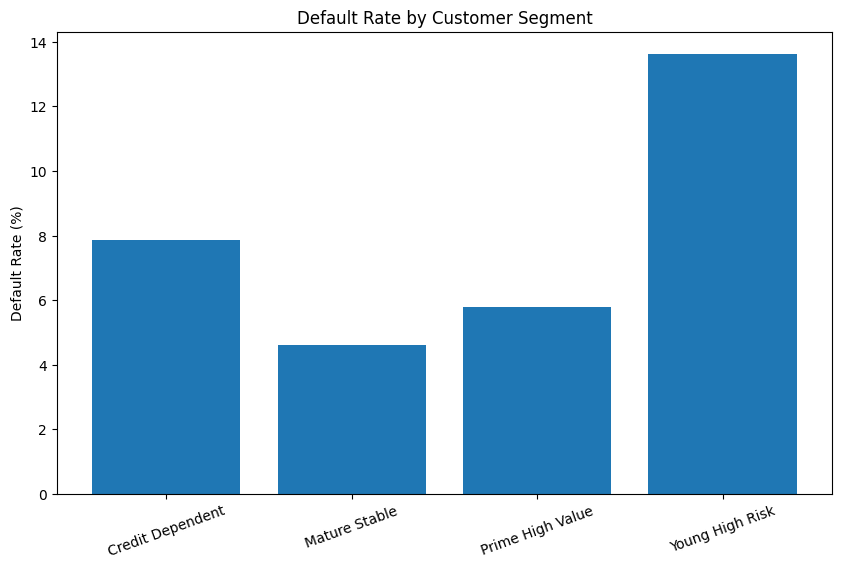

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(

    portfolio_summary["Segment"],

    portfolio_summary["Default_Rate"]

)

plt.xticks(rotation=20)

plt.ylabel("Default Rate (%)")

plt.title(
    "Default Rate by Customer Segment"
)

plt.show()

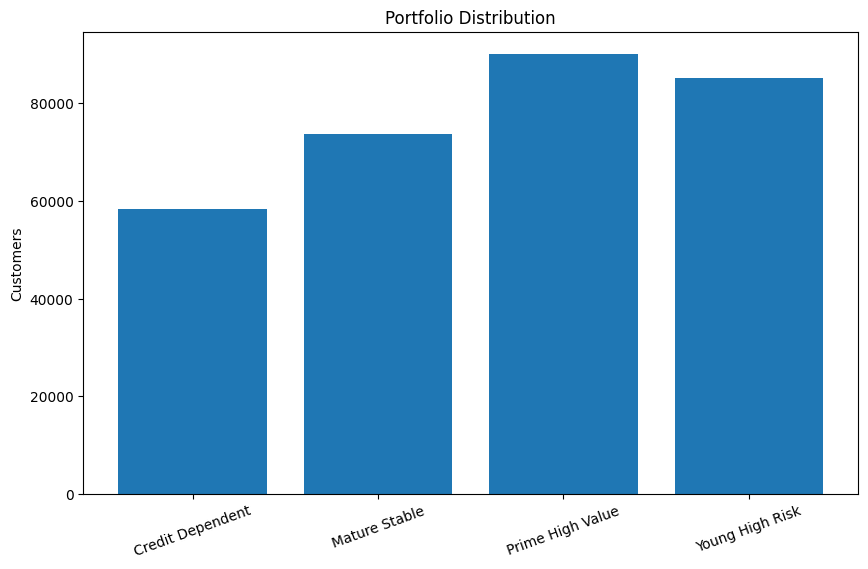

In [119]:
plt.figure(figsize=(10,6))

plt.bar(

    portfolio_summary["Segment"],

    portfolio_summary["Customer_Count"]

)

plt.xticks(rotation=20)

plt.ylabel("Customers")

plt.title(
    "Portfolio Distribution"
)

plt.show()

**What-If Simulator**

In [120]:
# currentt Portfolio risk
current_default_rate = (
    master_clean["TARGET"].mean()*100
)

print(
    "Current Portfolio Default Rate:",
    round(current_default_rate,2),
    "%"
)

Current Portfolio Default Rate: 8.07 %


In [121]:
# remove high risk Segment
optimized_portfolio = master_clean[
    master_clean["SEGMENT"]
    !=
    "Young High Risk"
]

In [122]:
# new portfolio risk
new_default_rate = (

    optimized_portfolio["TARGET"]

    .mean()

    *100

)

print(
    "Optimized Portfolio Default Rate:",
    round(new_default_rate,2),
    "%"
)

Optimized Portfolio Default Rate: 5.94 %


In [123]:
improvement = (

    current_default_rate

    -

    new_default_rate

)

print(

    "Risk Reduction:",

    round(improvement,2),

    "%"

)

Risk Reduction: 2.13 %


In [124]:
executive_summary = pd.DataFrame({

    "Metric":[

        "ROC AUC",

        "Current Portfolio Risk",

        "Optimized Portfolio Risk",

        "Risk Reduction"

    ],

    "Value":[

        0.777,

        round(current_default_rate,2),

        round(new_default_rate,2),

        round(improvement,2)

    ]

})

executive_summary

,Metric,Value
0,ROC AUC,0.777
1,Current Portfolio Risk,8.070
2,Optimized Portfolio Risk,5.940
3,Risk Reduction,2.130


**Business Recommendations**

In [125]:
recommendations = pd.DataFrame({

    "Recommendation":[

        "Increase lending to Mature Stable customers",

        "Increase lending to Prime High Value customers",

        "Monitor Credit Dependent customers",

        "Reduce exposure to Young High Risk customers",

        "Deploy Early Warning System for Red customers"

    ],

    "Expected Impact":[

        "Lower portfolio risk",

        "Higher profitability",

        "Lower delinquency",

        "Reduce defaults",

        "Proactive intervention"

    ]

})

recommendations

,Recommendation,Expected Impact
0,Increase lending to Mature Stable customers,Lower portfolio risk
1,Increase lending to Prime High Value customers,Higher profitability
2,Monitor Credit Dependent customers,Lower delinquency
3,Reduce exposure to Young High Risk customers,Reduce defaults
4,Deploy Early Warning System for Red customers,Proactive intervention


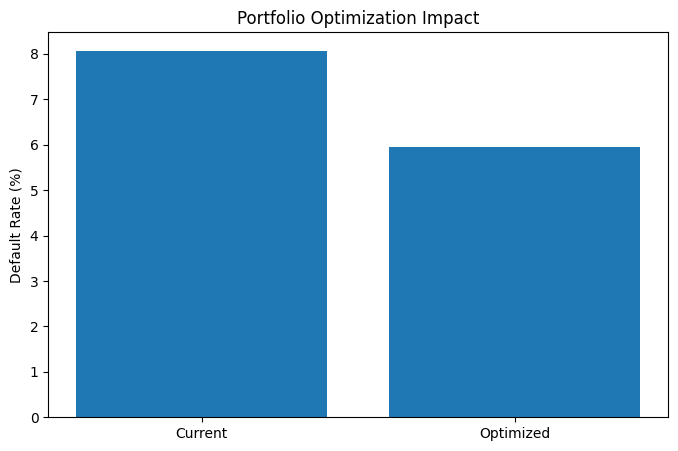

In [126]:
plt.figure(figsize=(8,5))

plt.bar(

    ["Current","Optimized"],

    [current_default_rate,
     new_default_rate]

)

plt.ylabel("Default Rate (%)")

plt.title(
    "Portfolio Optimization Impact"
)

plt.show()

In [127]:
master_clean.to_csv(
    "final_credit_risk_dataset.csv",
    index=False
)

**Serializing model and making it Deployment ready**

In [128]:
import joblib

joblib.dump(
    lgbm,
    "lightgbm_model.pkl"
)

['lightgbm_model.pkl']

In [129]:
model = joblib.load(
    "lightgbm_model.pkl"
)

In [130]:
prob = model.predict_proba(
    X_test.iloc[[0]]
)[0][1]

print(prob)

0.2761756992358754


In [131]:
import joblib

joblib.dump(
    lgbm,
    "credit_risk_model.pkl"
)

print("Model Saved")

Model Saved


In [132]:
model = joblib.load(
    "credit_risk_model.pkl"
)

print(model)

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, max_depth=8, n_estimators=300,
               random_state=42, subsample=0.8)


In [133]:
dashboard_df = master_clean[[
    "SK_ID_CURR",
    "TARGET",
    "SEGMENT",
    "EARLY_WARNING",
    "PERSONA",
    "RISK_BAND",
    "EXT_RISK_SCORE",
    "FINANCIAL_STRESS_SCORE",
    "CUSTOMER_VALUE_SCORE",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT"
]].copy()

In [134]:
dashboard_df["DEFAULT_PROBABILITY"] = (
    lgbm.predict_proba(X)[:,1]
)

In [135]:
dashboard_df.to_csv(
    "powerbi_dashboard_data.csv",
    index=False
)

In [136]:
joblib.dump(lgbm,"credit_risk_model.pkl")

['credit_risk_model.pkl']

In [137]:
joblib.dump(X.columns.tolist(),"model_columns.pkl")

['model_columns.pkl']

In [138]:
import os

for file in os.listdir('/kaggle/working'):
    print(file)

master_dataset_v2.parquet
master_dataset_v1.parquet
lightgbm_model.pkl
__notebook__.ipynb
master_dataset_v1.csv
powerbi_dashboard_data.csv
final_credit_risk_dataset.csv
credit_risk_model.pkl
model_columns.pkl


In [139]:
import zipfile

files_to_zip = [
    "credit_risk_model.pkl",
    "lightgbm_model.pkl",
    "model_columns.pkl",
    "final_credit_risk_dataset.csv"
]

with zipfile.ZipFile(
    "credit_risk_project_files.zip",
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)

print("ZIP created successfully")

ZIP created successfully
